# MiniRepair-RL Results Visualization

This notebook generates all key visualizations for the MiniRepair-RL project:
1. Cross-method comparison (bar chart)
2. Per-task pass/fail heatmap
3. Behavioral analysis (tool usage, guardrails)
4. Failure category distribution
5. Public vs Hidden pass gap
6. RL training curves (sparse vs dense)

In [11]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

ROOT = Path('..')
REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

## Load Data

In [12]:
# Load test split metrics for all 4 methods
methods = {
    'ReAct': 'react_test_full',
    'SFT': 'sft_test_full',
    'RL Sparse': 'rl_sparse_test_trained',
    'RL Dense': 'rl_dense_test_trained',
}

test_dfs = {}
test_summaries = {}
for name, dirname in methods.items():
    base = ROOT / 'logs' / 'eval' / dirname
    test_dfs[name] = pd.read_csv(base / 'metrics.csv')
    with open(base / 'summary.json') as f:
        test_summaries[name] = json.load(f)

# Load validation split metrics
val_methods = {
    'ReAct': 'react_validation_full',
    'SFT': 'sft_validation_full',
    'RL Sparse': 'rl_sparse_validation_trained',
    'RL Dense': 'rl_dense_validation_trained',
}

val_dfs = {}
val_summaries = {}
for name, dirname in val_methods.items():
    base = ROOT / 'logs' / 'eval' / dirname
    val_dfs[name] = pd.read_csv(base / 'metrics.csv')
    with open(base / 'summary.json') as f:
        val_summaries[name] = json.load(f)

# Load RL training curves
rl_curves = {}
for label, path in [
    ('Sparse', ROOT / 'outputs' / 'rl_sparse_adapter_trained' / 'curves.json'),
    ('Dense', ROOT / 'outputs' / 'rl_dense_adapter_trained' / 'curves.json'),
]:
    with open(path) as f:
        rl_curves[label] = json.load(f)

print('Loaded test data:', {k: len(v) for k, v in test_dfs.items()})
print('Loaded val data:', {k: len(v) for k, v in val_dfs.items()})

Loaded test data: {'ReAct': 30, 'SFT': 30, 'RL Sparse': 30, 'RL Dense': 30}
Loaded val data: {'ReAct': 20, 'SFT': 20, 'RL Sparse': 20, 'RL Dense': 20}


## 1. Cross-Method Comparison (Test Split)

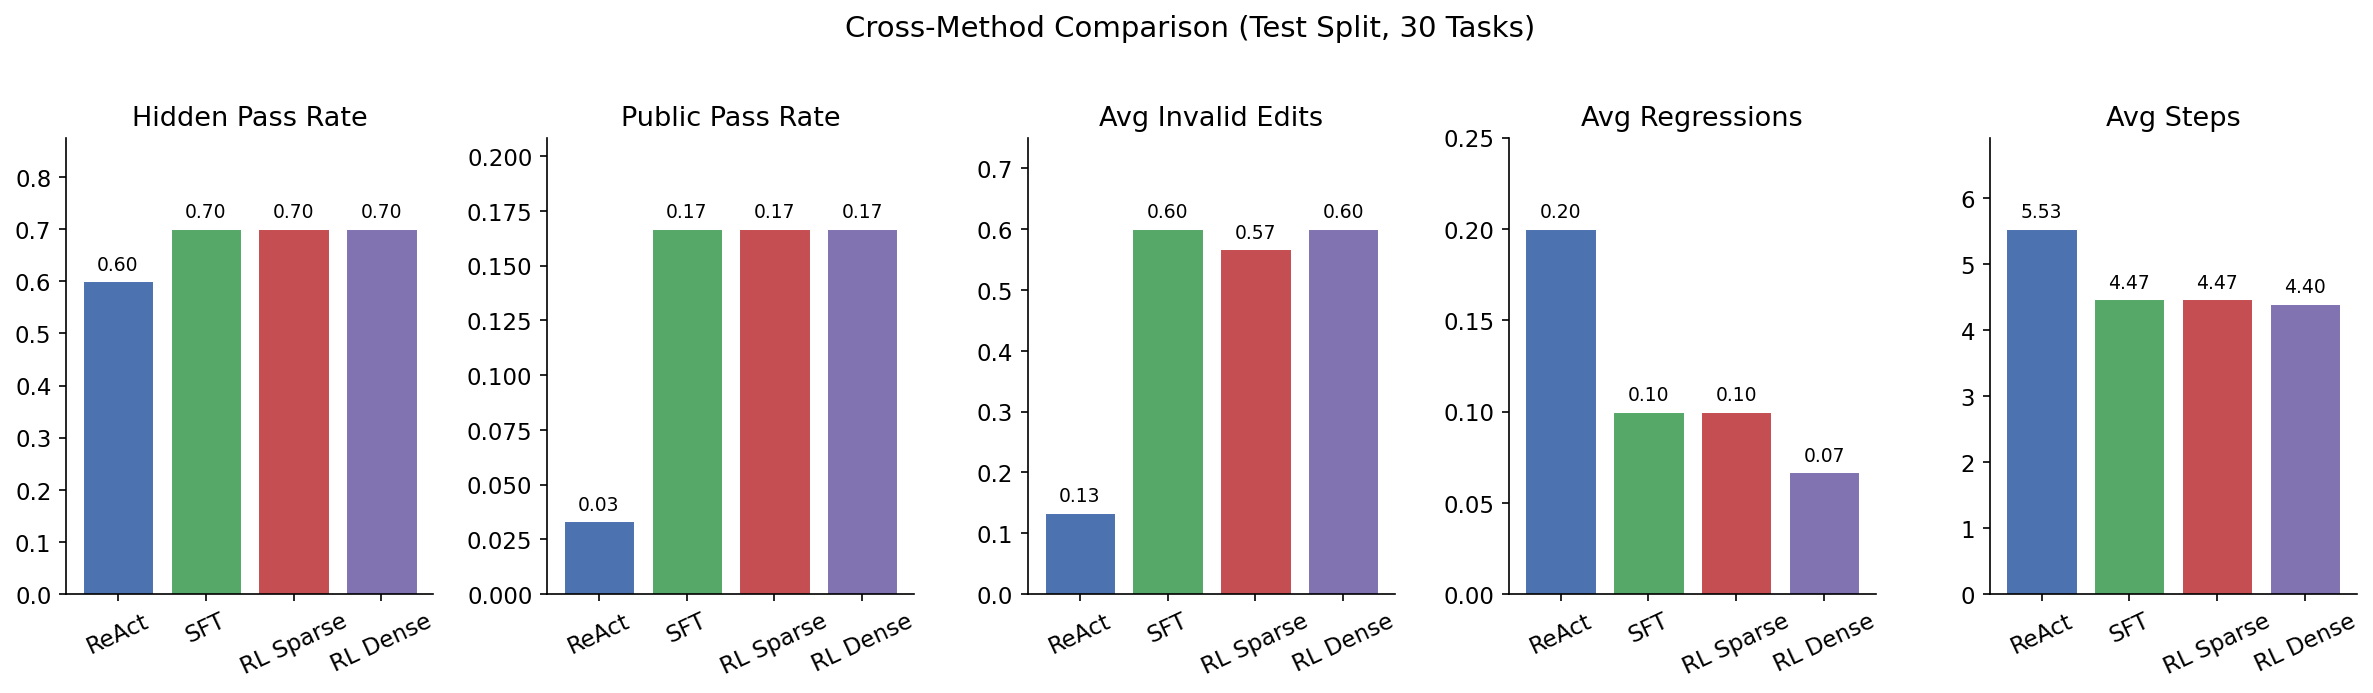

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))
method_names = list(methods.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

metrics = [
    ('hidden_pass_rate', 'Hidden Pass Rate'),
    ('public_pass_rate', 'Public Pass Rate'),
    ('avg_invalid_edits', 'Avg Invalid Edits'),
    ('avg_regressions', 'Avg Regressions'),
    ('avg_steps', 'Avg Steps'),
]

for ax, (key, title) in zip(axes, metrics):
    vals = [test_summaries[m].get(key, 0) for m in method_names]
    bars = ax.bar(method_names, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_ylim(0, max(vals) * 1.25 if max(vals) > 0 else 1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    ax.tick_params(axis='x', rotation=25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Cross-Method Comparison (Test Split, 30 Tasks)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_cross_method_comparison.png')
plt.show()

## 2. Per-Task Pass/Fail Heatmap (Test Split)

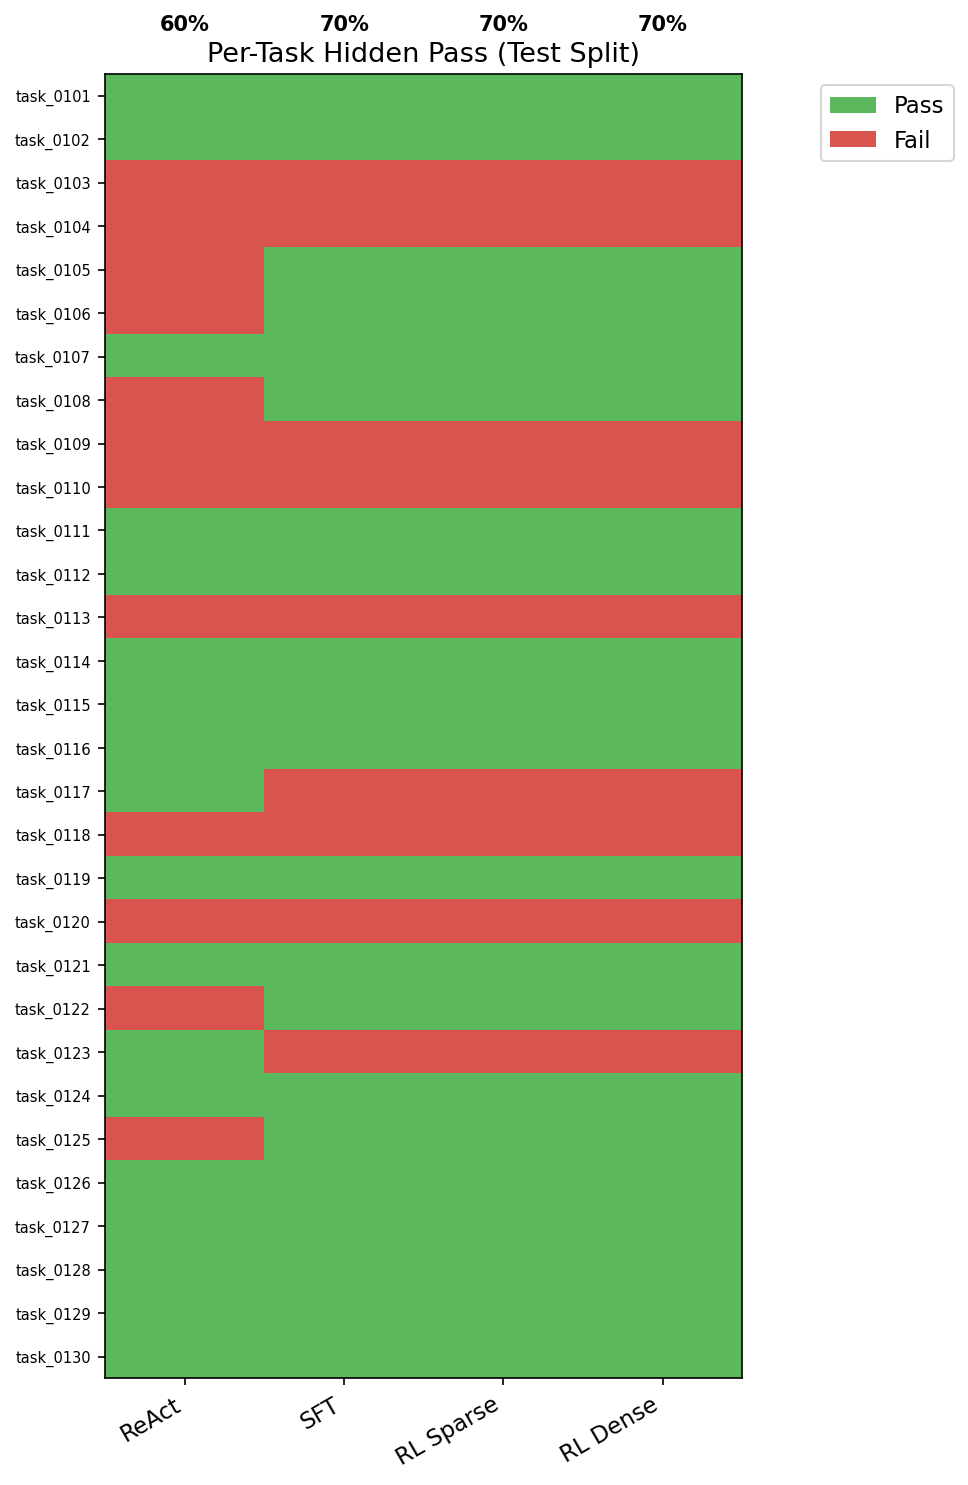

All 4 methods pass: 16/30
All 4 methods fail: 7/30
Disagreement: 7/30


In [14]:
# Build a matrix: rows = tasks, cols = methods, values = hidden_pass
task_ids = sorted(test_dfs['ReAct']['task_id'].unique())
matrix = np.zeros((len(task_ids), len(method_names)))

for j, name in enumerate(method_names):
    df = test_dfs[name].set_index('task_id')
    for i, tid in enumerate(task_ids):
        val = df.loc[tid, 'hidden_pass'] if tid in df.index else False
        matrix[i, j] = 1 if str(val).lower() == 'true' else 0

fig, ax = plt.subplots(figsize=(7, 10))
cmap = plt.cm.colors.ListedColormap(['#d9534f', '#5cb85c'])
im = ax.imshow(matrix, cmap=cmap, aspect='auto', interpolation='nearest')

ax.set_xticks(range(len(method_names)))
ax.set_xticklabels(method_names, rotation=30, ha='right')
ax.set_yticks(range(len(task_ids)))
ax.set_yticklabels(task_ids, fontsize=7)
ax.set_title('Per-Task Hidden Pass (Test Split)')

# Count pass rates per method
for j, name in enumerate(method_names):
    rate = matrix[:, j].mean()
    ax.text(j, -1.5, f'{rate:.0%}', ha='center', fontsize=10, fontweight='bold')

# Legend
ax.legend(handles=[Patch(facecolor='#5cb85c', label='Pass'), Patch(facecolor='#d9534f', label='Fail')],
          loc='upper right', bbox_to_anchor=(1.35, 1.0))

plt.tight_layout()
plt.savefig(REPORTS / 'fig_task_heatmap.png')
plt.show()

# Print agreement stats
all_pass = (matrix.sum(axis=1) == 4).sum()
all_fail = (matrix.sum(axis=1) == 0).sum()
print(f'All 4 methods pass: {all_pass}/{len(task_ids)}')
print(f'All 4 methods fail: {all_fail}/{len(task_ids)}')
print(f'Disagreement: {len(task_ids) - all_pass - all_fail}/{len(task_ids)}')

## 3. Behavioral Analysis — Tool Usage & Guardrails

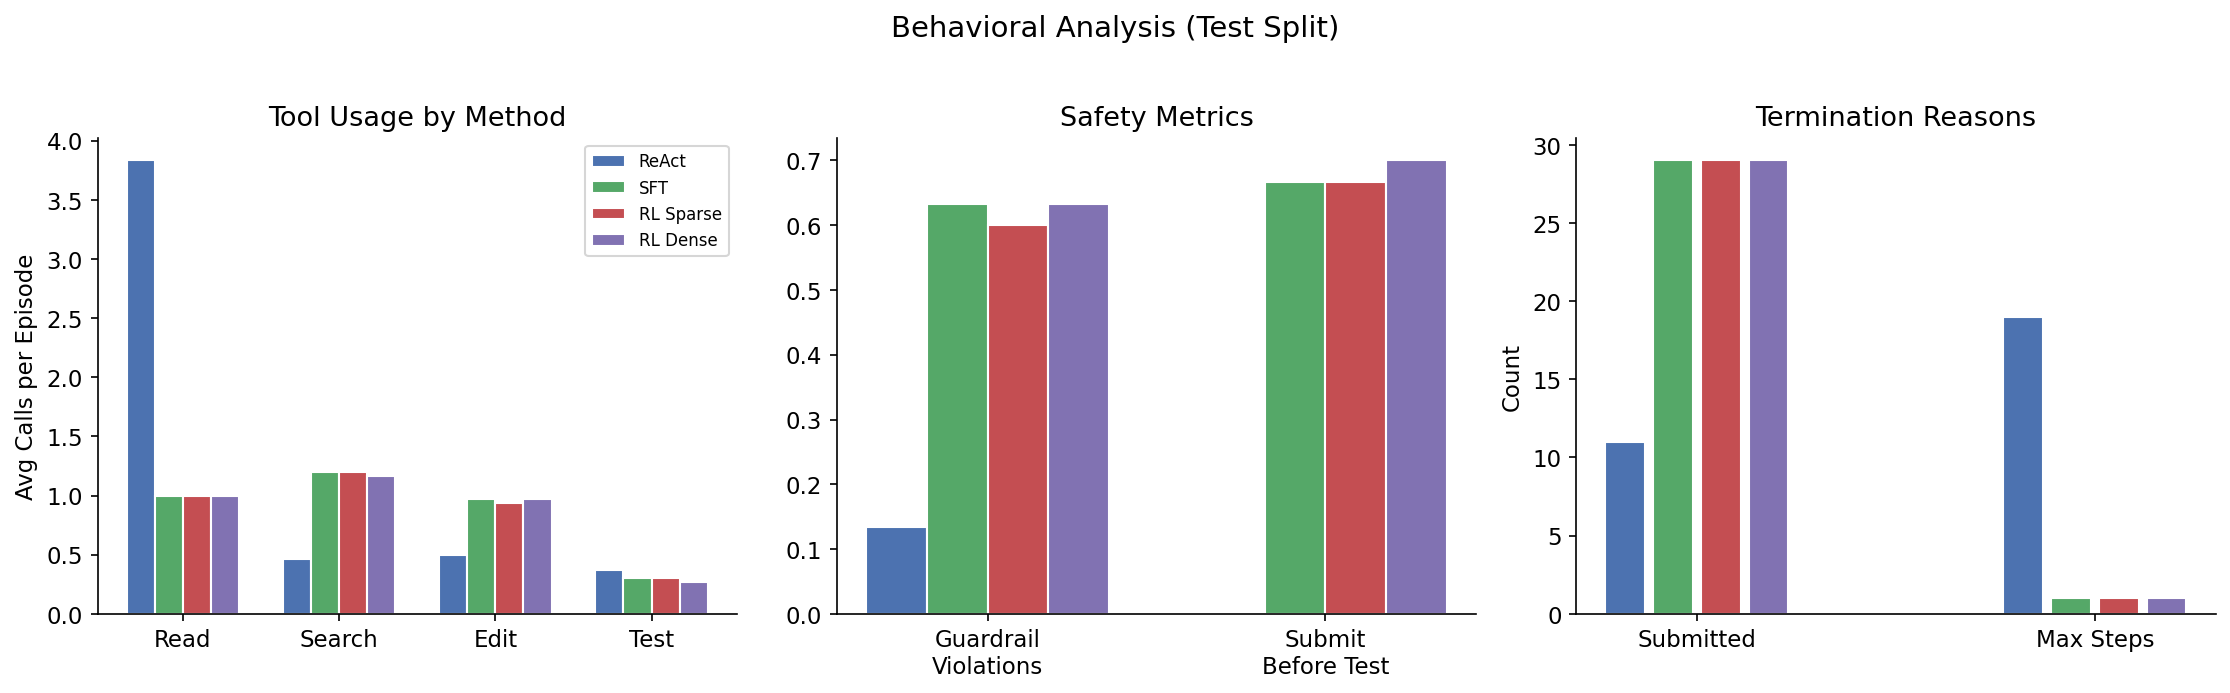

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Tool call distribution per method
tool_cols = ['avg_read_calls', 'avg_search_calls', 'avg_edit_calls', 'avg_test_calls']
tool_labels = ['Read', 'Search', 'Edit', 'Test']
x = np.arange(len(tool_labels))
width = 0.18

ax = axes[0]
for i, name in enumerate(method_names):
    vals = [test_summaries[m].get(c, 0) for c in tool_cols for m in [name] if m == name]
    vals = [test_summaries[name].get(c, 0) for c in tool_cols]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i], edgecolor='white')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(tool_labels)
ax.set_ylabel('Avg Calls per Episode')
ax.set_title('Tool Usage by Method')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (b) Guardrail violations & submit-before-test
ax = axes[1]
bar_metrics = ['avg_guardrail_violations', 'submit_before_test_rate']
bar_labels = ['Guardrail\nViolations', 'Submit\nBefore Test']
x2 = np.arange(len(bar_labels))

for i, name in enumerate(method_names):
    vals = [test_summaries[name].get(c, 0) for c in bar_metrics]
    ax.bar(x2 + i * width, vals, width, label=name, color=colors[i], edgecolor='white')
ax.set_xticks(x2 + 1.5 * width)
ax.set_xticklabels(bar_labels)
ax.set_title('Safety Metrics')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# (c) Termination reasons
ax = axes[2]
reasons = ['submitted', 'max_steps']
for i, name in enumerate(method_names):
    df = test_dfs[name]
    counts = [(df['termination_reason'] == r).sum() for r in reasons]
    ax.bar([r + i * 0.12 for r in range(len(reasons))], counts, 0.1,
           label=name, color=colors[i], edgecolor='white')
ax.set_xticks([r + 0.18 for r in range(len(reasons))])
ax.set_xticklabels(['Submitted', 'Max Steps'])
ax.set_ylabel('Count')
ax.set_title('Termination Reasons')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.suptitle('Behavioral Analysis (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_behavioral_analysis.png')
plt.show()

## 4. Failure Category Distribution

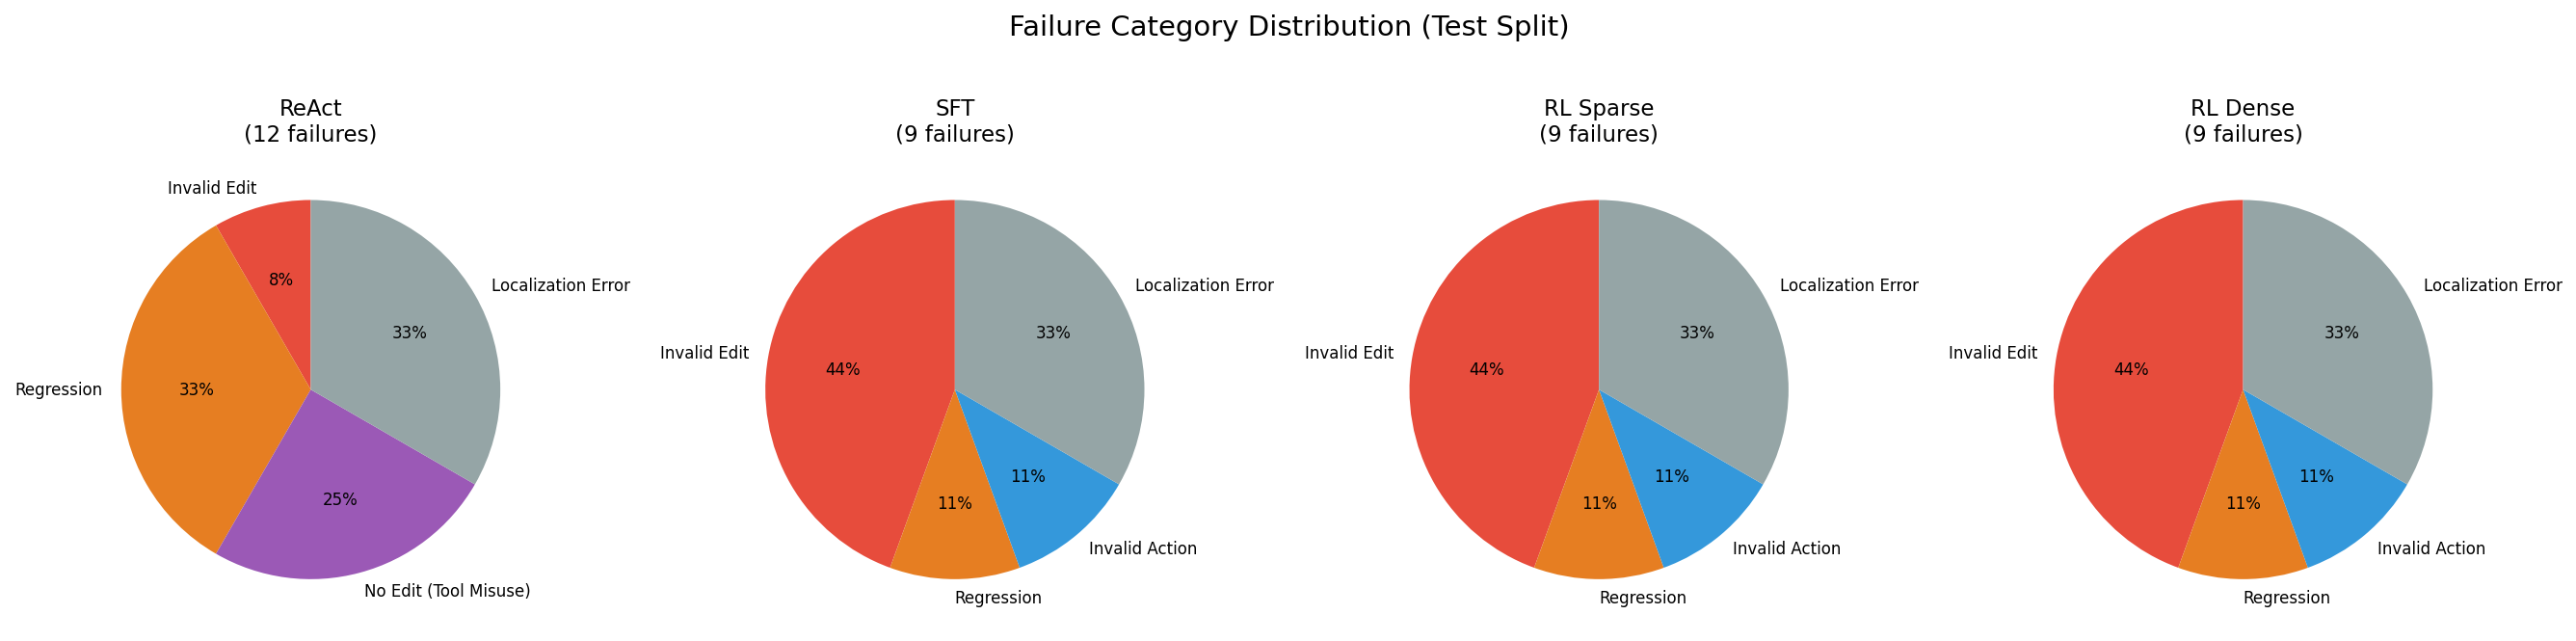

In [16]:
# Classify each failed episode by primary failure category
def classify_failure(row):
    if row.get('invalid_action_count', 0) > 0:
        return 'Invalid Action'
    if row.get('invalid_edit_count', 0) > 0:
        return 'Invalid Edit'
    if row.get('regression_count', 0) > 0:
        return 'Regression'
    if row.get('submit_before_test', False) or str(row.get('submit_before_test', '')).lower() == 'true':
        return 'Premature Submit'
    if row.get('edit_count', 0) == 0:
        return 'No Edit (Tool Misuse)'
    return 'Localization Error'

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
categories = ['Invalid Edit', 'Regression', 'No Edit (Tool Misuse)', 'Invalid Action',
              'Premature Submit', 'Localization Error']
cat_colors = ['#e74c3c', '#e67e22', '#9b59b6', '#3498db', '#1abc9c', '#95a5a6']

for ax, name in zip(axes, method_names):
    df = test_dfs[name]
    failed = df[df['hidden_pass'].astype(str).str.lower() != 'true']
    if len(failed) == 0:
        ax.set_title(f'{name}\n(No failures)')
        continue
    cats = failed.apply(classify_failure, axis=1)
    counts = cats.value_counts()
    ordered = [counts.get(c, 0) for c in categories]
    nonzero = [(c, v, col) for c, v, col in zip(categories, ordered, cat_colors) if v > 0]
    if nonzero:
        labels, vals, cols = zip(*nonzero)
        ax.pie(vals, labels=labels, colors=cols, autopct='%1.0f%%', startangle=90,
               textprops={'fontsize': 8})
    ax.set_title(f'{name}\n({len(failed)} failures)', fontsize=11)

fig.suptitle('Failure Category Distribution (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_failure_distribution.png')
plt.show()

## 5. Public vs Hidden Pass Gap

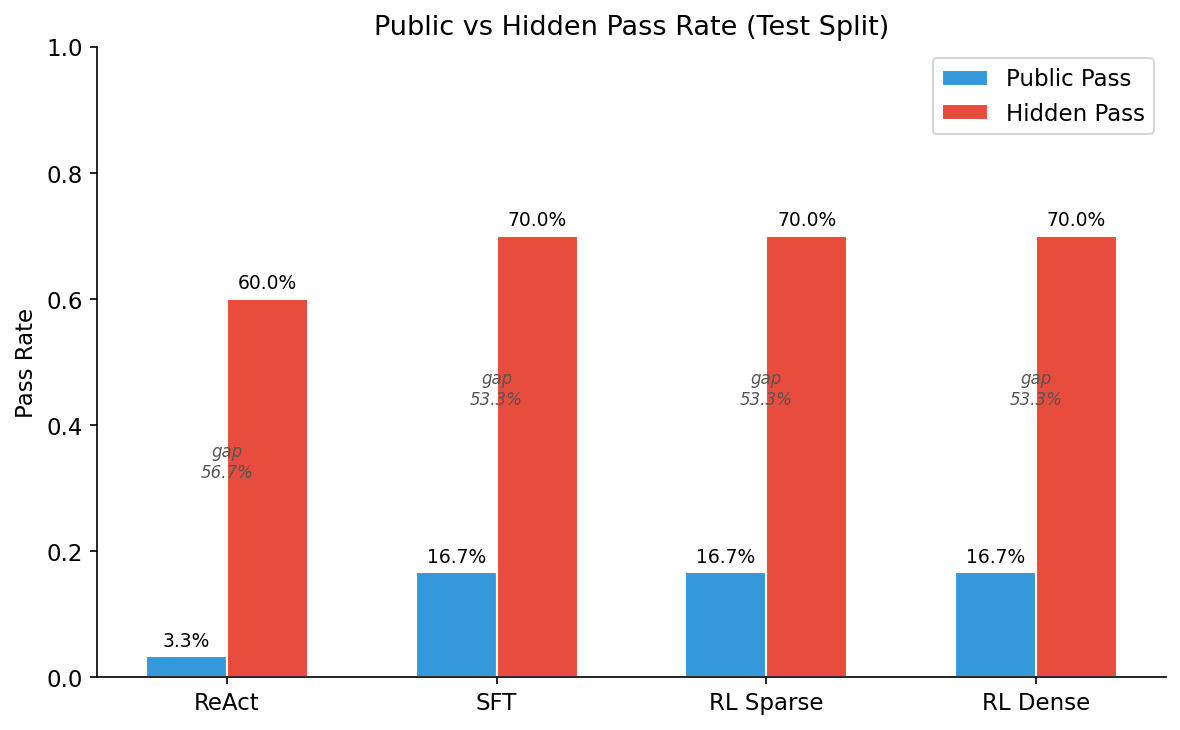

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(method_names))
width = 0.3
pub_rates = [test_summaries[m]['public_pass_rate'] for m in method_names]
hid_rates = [test_summaries[m]['hidden_pass_rate'] for m in method_names]

bars1 = ax.bar(x - width/2, pub_rates, width, label='Public Pass', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + width/2, hid_rates, width, label='Hidden Pass', color='#e74c3c', edgecolor='white')

for bar, v in zip(bars1, pub_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.1%}', ha='center', va='bottom', fontsize=9)
for bar, v in zip(bars2, hid_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.1%}', ha='center', va='bottom', fontsize=9)

# Draw gap arrows
for i in range(len(method_names)):
    gap = hid_rates[i] - pub_rates[i]
    mid_y = (pub_rates[i] + hid_rates[i]) / 2
    ax.annotate(f'gap\n{gap:.1%}', xy=(i, mid_y), ha='center', fontsize=8,
                color='#555', fontstyle='italic')

ax.set_xticks(x)
ax.set_xticklabels(method_names)
ax.set_ylabel('Pass Rate')
ax.set_title('Public vs Hidden Pass Rate (Test Split)')
ax.set_ylim(0, 1.0)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(REPORTS / 'fig_public_hidden_gap.png')
plt.show()

## 6. RL Training Curves (Sparse vs Dense)

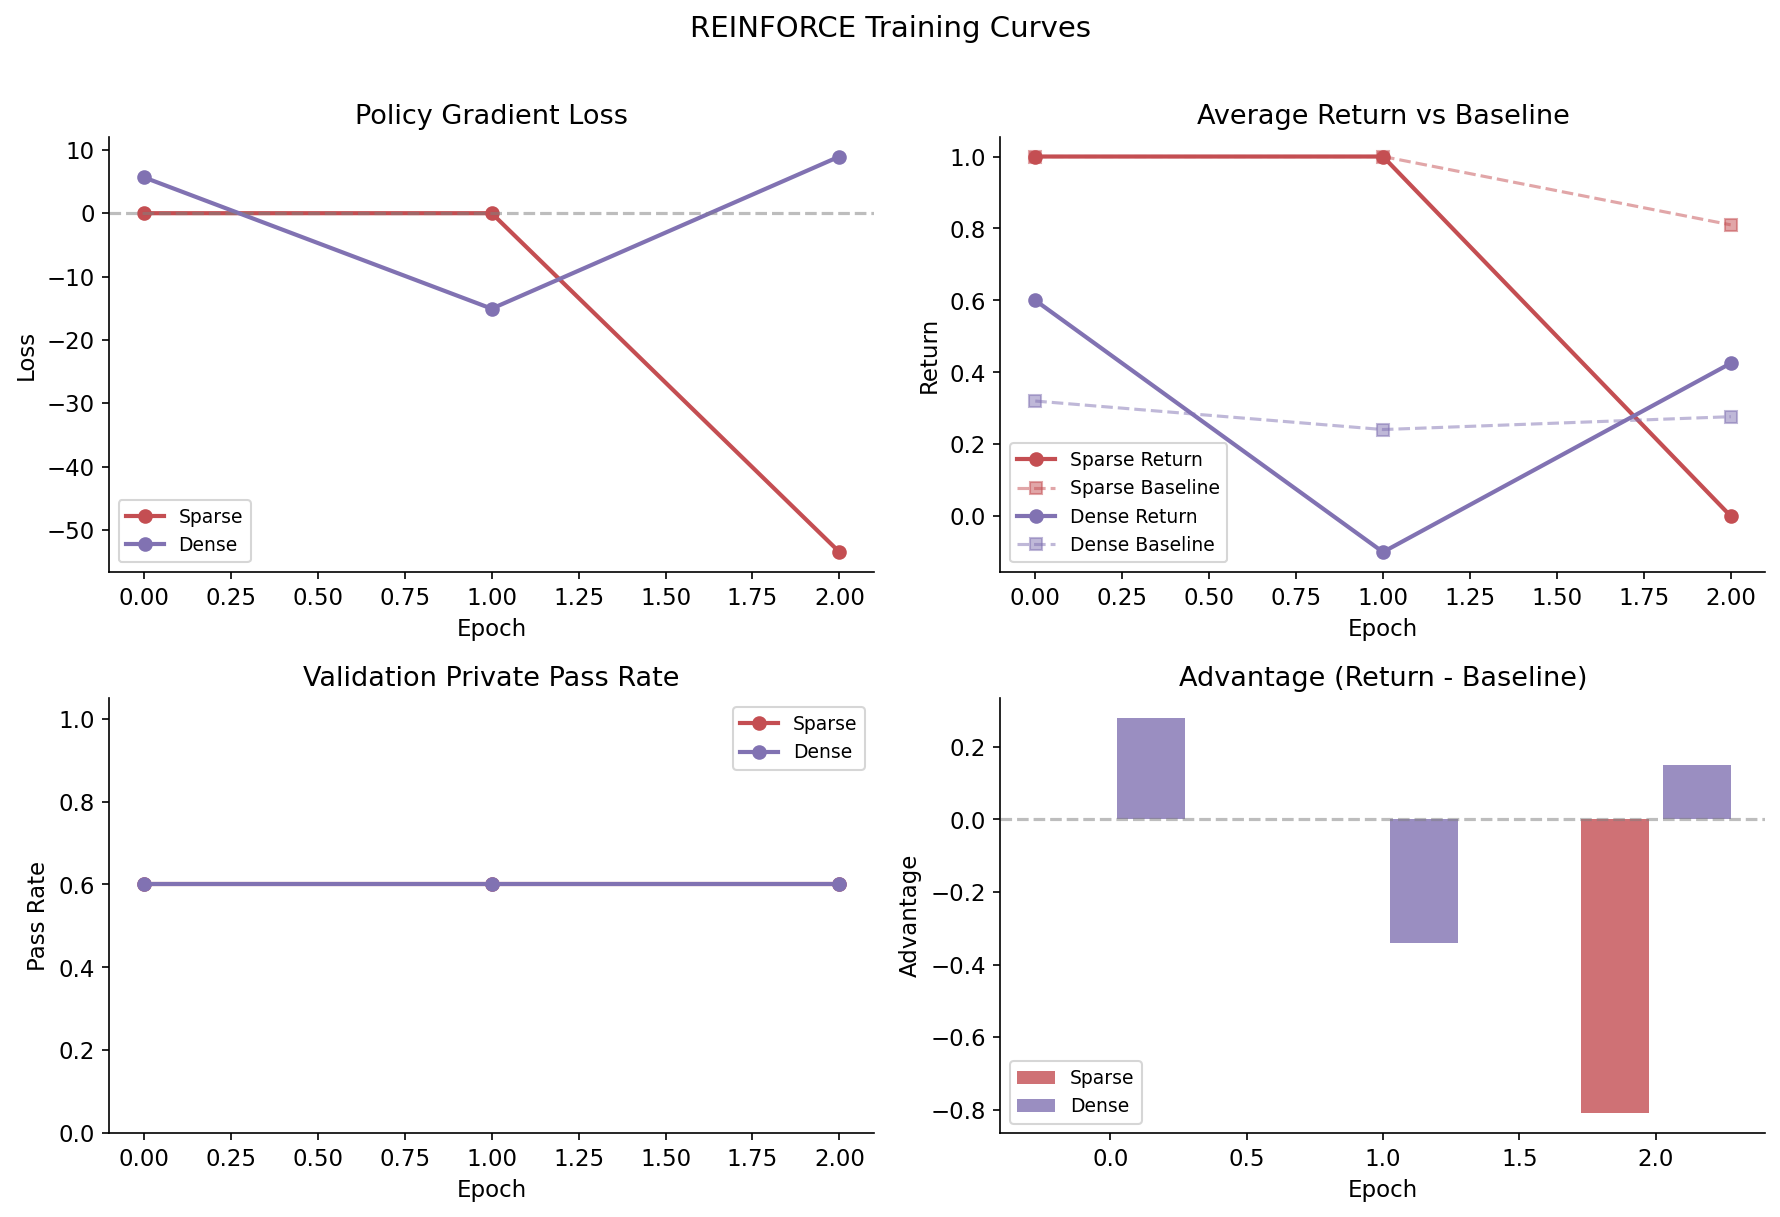

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
rl_colors = {'Sparse': '#C44E52', 'Dense': '#8172B2'}

for label, curves in rl_curves.items():
    epochs = curves['epoch']
    c = rl_colors[label]

    # (a) Loss
    axes[0, 0].plot(epochs, curves['loss'], 'o-', color=c, label=label, linewidth=2)
    axes[0, 0].set_title('Policy Gradient Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.3)

    # (b) Return vs Baseline
    axes[0, 1].plot(epochs, curves['avg_return'], 'o-', color=c, label=f'{label} Return', linewidth=2)
    axes[0, 1].plot(epochs, curves['baseline'], 's--', color=c, alpha=0.5, label=f'{label} Baseline')
    axes[0, 1].set_title('Average Return vs Baseline')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Return')

    # (c) Validation private pass
    axes[1, 0].plot(epochs, curves['val_private_pass'], 'o-', color=c, label=label, linewidth=2)
    axes[1, 0].set_title('Validation Private Pass Rate')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Pass Rate')
    axes[1, 0].set_ylim(0, 1.05)

    # (d) Advantage
    advantage = [r - b for r, b in zip(curves['avg_return'], curves['baseline'])]
    bar_colors = ['#5cb85c' if a >= 0 else '#d9534f' for a in advantage]
    axes[1, 1].bar([e + (0.15 if label == 'Dense' else -0.15) for e in epochs],
                   advantage, 0.25, color=c, alpha=0.8, label=label)
    axes[1, 1].set_title('Advantage (Return - Baseline)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Advantage')
    axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.3)

for ax in axes.flat:
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('REINFORCE Training Curves', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_rl_training_curves.png')
plt.show()

## 7. Per-Task Metric Breakdown (Test Split)

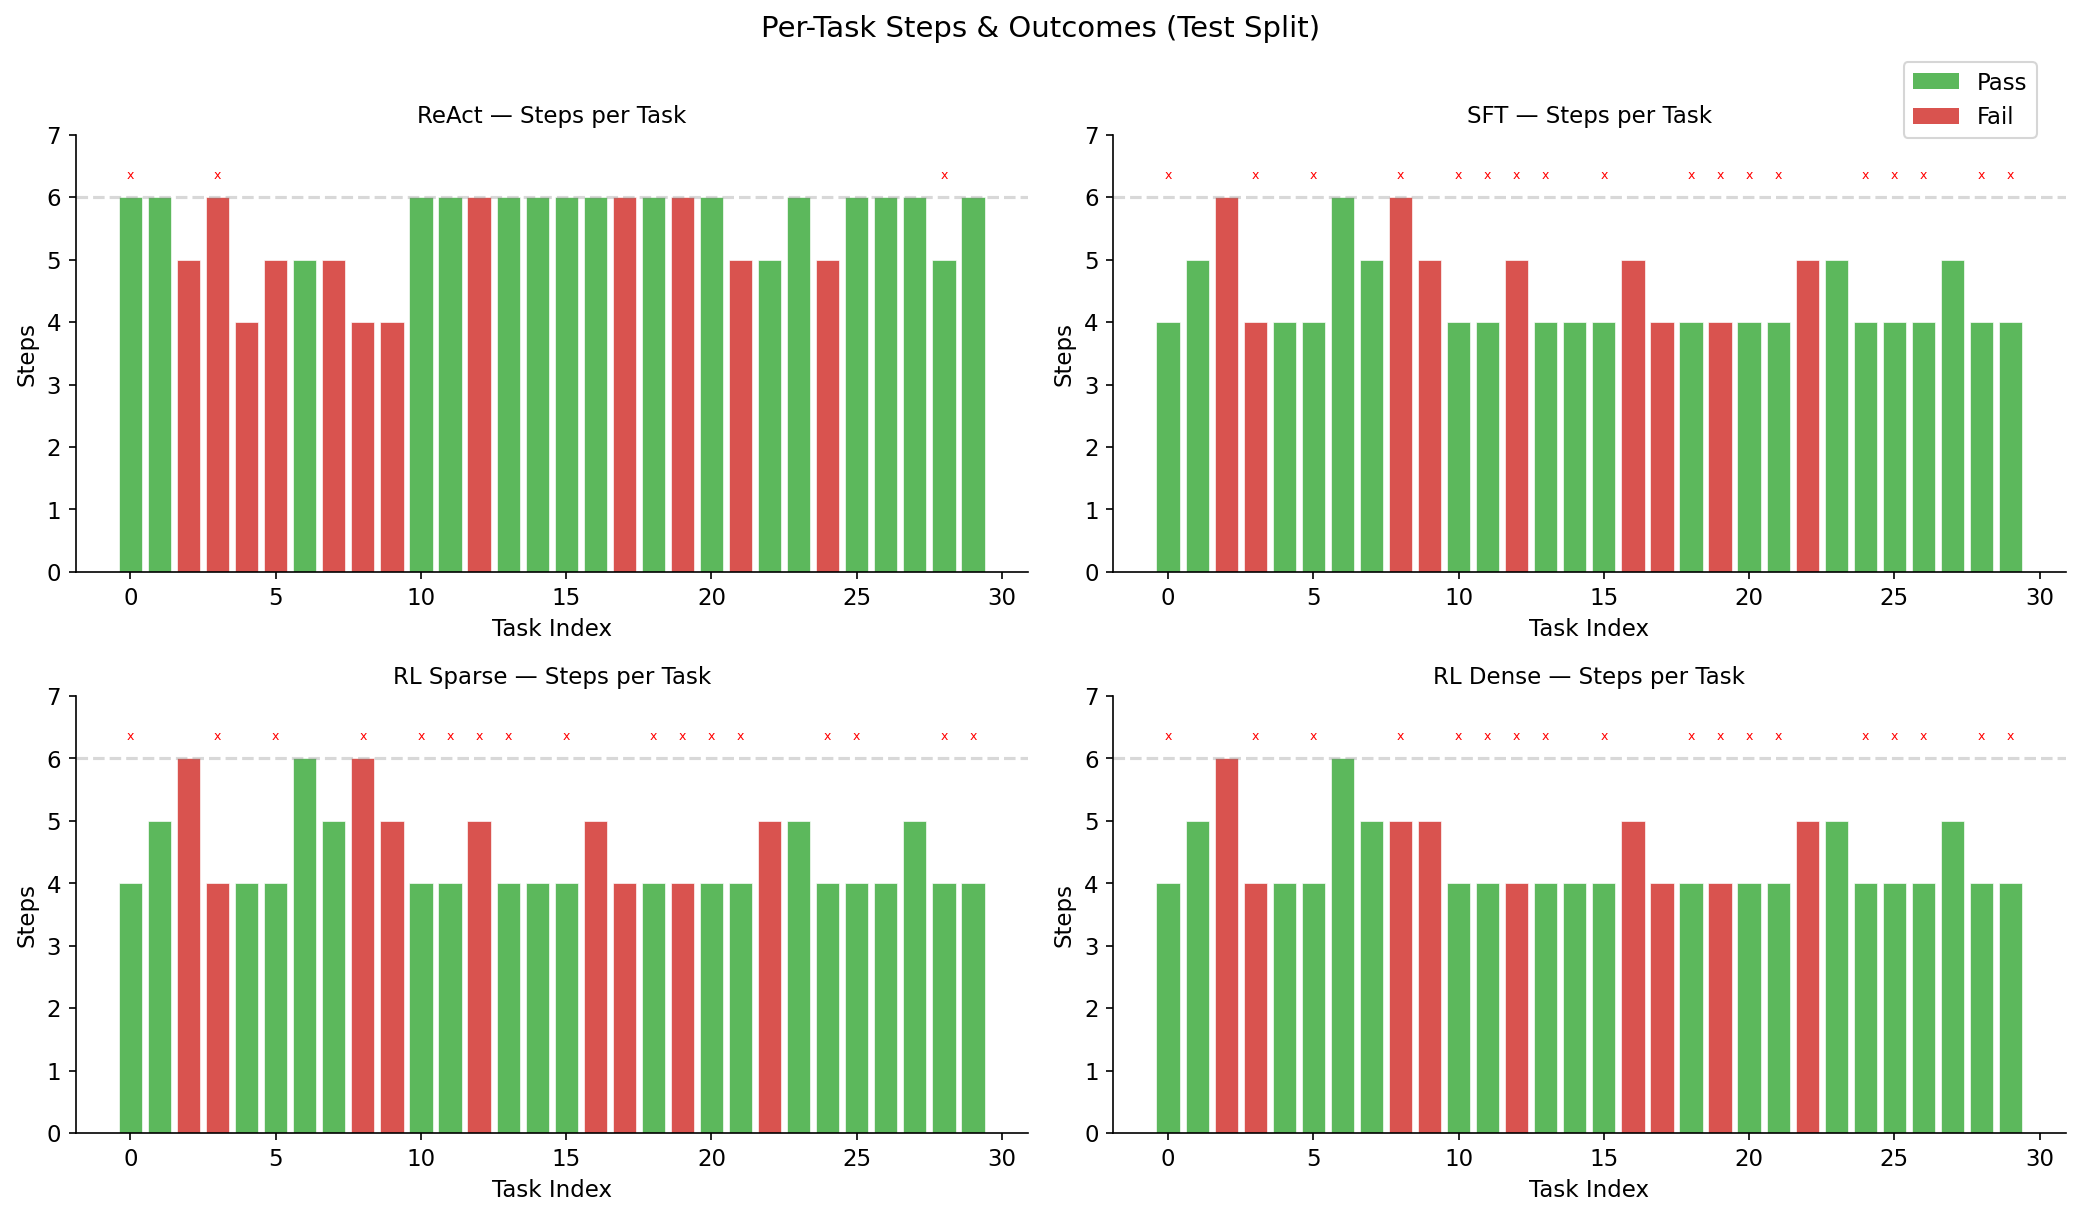

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, name in zip(axes.flat, method_names):
    df = test_dfs[name].copy()
    df['passed'] = df['hidden_pass'].astype(str).str.lower() == 'true'
    df = df.sort_values('task_id')

    x = range(len(df))
    bar_colors = ['#5cb85c' if p else '#d9534f' for p in df['passed']]

    ax.bar(x, df['total_steps'], color=bar_colors, edgecolor='white', linewidth=0.3)
    ax.set_title(f'{name} — Steps per Task', fontsize=11)
    ax.set_xlabel('Task Index')
    ax.set_ylabel('Steps')
    ax.set_ylim(0, 7)
    ax.axhline(6, color='gray', linestyle='--', alpha=0.3, label='Max Steps')

    # Mark invalid edits
    for i, (_, row) in enumerate(df.iterrows()):
        if row['invalid_edit_count'] > 0:
            ax.text(i, 6.3, 'x', ha='center', fontsize=6, color='red')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.legend(handles=[Patch(facecolor='#5cb85c', label='Pass'),
                     Patch(facecolor='#d9534f', label='Fail')],
           loc='upper right', bbox_to_anchor=(0.98, 0.98))
fig.suptitle('Per-Task Steps & Outcomes (Test Split)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_per_task_steps.png')
plt.show()

## 8. Summary Table

In [20]:
# Print a compact comparison table
rows = []
for name in method_names:
    s = test_summaries[name]
    rows.append({
        'Method': name,
        'Hidden Pass': f"{s['hidden_pass_rate']:.1%}",
        'Public Pass': f"{s['public_pass_rate']:.1%}",
        'Invalid Edit': f"{s['avg_invalid_edits']:.2f}",
        'Regression': f"{s['avg_regressions']:.2f}",
        'Avg Steps': f"{s['avg_steps']:.2f}",
        'Guardrail': f"{s['avg_guardrail_violations']:.2f}",
        'Submit< Test': f"{s['submit_before_test_rate']:.1%}",
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

   Method Hidden Pass Public Pass Invalid Edit Regression Avg Steps Guardrail Submit< Test
    ReAct       60.0%        3.3%         0.13       0.20      5.53      0.13         0.0%
      SFT       70.0%       16.7%         0.60       0.10      4.47      0.63        66.7%
RL Sparse       70.0%       16.7%         0.57       0.10      4.47      0.60        66.7%
 RL Dense       70.0%       16.7%         0.60       0.07      4.40      0.63        70.0%
